In [1]:
import pandas as pd
import numpy as np
import os 
import json
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import h5py

In [2]:
DATAFILE = 'MIMICExtractEasy/data/extract/all_hourly_data.h5'
labs = pd.read_hdf(DATAFILE,'vitals_labs').xs('mean', axis=1, level='Aggregation Function')
inter = pd.read_hdf(DATAFILE,'interventions')
pat = pd.read_hdf(DATAFILE,'patients')

BIN_HOURS   = 24                  # Number of hours to group together (for now)
LAB_FRAC    = 0.2                 # drop any labs that are recorded in less than this % of time bins 

In [3]:
# Only include those who lived longer than 1 day
pat = pat[np.logical_or((pat['deathtime'] - pat['admittime']) >= pd.Timedelta('1 days'), pat['deathtime'].isnull())]

# Must have stayed for longer than 1 day
pat = pat[pat['los_icu'] >= 1]

# age < 200
pat = pat[pat['age'] < 200]

pat.shape

(27594, 29)

In [4]:
def aggregate_to_bins(df, bin_hours=4):
    """
    Aggregate multi-indexed (subject_id, hadm_id, icustay_id, hours_in) 
    dataframe to N-hour bins by taking mean of observed values.
    
    df: labs or interventions dataframe with hours_in in index
    """
    # Reset to make hours_in a column
    df_reset = df.reset_index()
    
    # Create bin column
    df_reset['time_bin'] = (df_reset['hours_in'] // bin_hours).astype(int)
    
    # Group by patient + time bin, aggregate
    # For continuous (labs): take mean of observed values
    # For binary (interventions): take max (1 if occurred at any point in bin)
    agg_funcs = {}
    for col in df.columns:
        # Interventions are binary (0/1), labs are continuous
        # Use max for binary (captures "did this happen in the bin?")
        # Use mean for continuous (average level during bin)
        if df[col].dtype in ['float64', 'float32']:
            # Continuous lab value
            agg_funcs[col] = 'mean'#, 'max', 'min'
        else:
            # Binary intervention
            agg_funcs[col] = 'max'#, 'mean'
    
    df_binned = df_reset.groupby(
        ['subject_id', 'hadm_id', 'icustay_id', 'time_bin']
    ).agg(agg_funcs)
    
    # Rename time_bin back to hours_in for compatibility
    df_binned = df_binned.reset_index()
    df_binned['hours_in'] = df_binned['time_bin'] * bin_hours
    df_binned = df_binned.drop(columns=['time_bin'])
    df_binned = df_binned.set_index(['subject_id', 'hadm_id', 'icustay_id', 'hours_in'])
    
    return df_binned

# Simplify data by aggregating across multiple hours
labs  = aggregate_to_bins(labs, bin_hours=BIN_HOURS)
inter = aggregate_to_bins(inter, bin_hours=BIN_HOURS)

In [5]:
# clean ethnicity column
eth_map = {'UNKNOWN/NOT SPECIFIED': 'UNKNOWN', 'UNABLE TO OBTAIN': 'UNKNOWN', 'PATIENT DECLINED TO ANSWER': 'UNKNOWN',
           'HISPANIC OR LATINO': 'HISPANIC/LATINO', 'BLACK/CAPE VERDEAN': 'BLACK/AFRICAN AMERICAN', 'BLACK/HAITIAN':'BLACK/AFRICAN AMERICAN',
           'SOUTH AMERICAN': 'HISPANIC/LATINO', 'MULTI RACE ETHNICITY': 'OTHER', 'PORTUGUESE': 'OTHER', 'BLACK/AFRICAN': 'BLACK/AFRICAN AMERICAN',
           'MIDDLE EASTERN': 'OTHER', 'AMERICAN INDIAN/ALASKA NATIVE': 'OTHER', 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER': 'OTHER', 'CARIBBEAN ISLAND': 'OTHER',
           'AMERICAN INDIAN/ALASKA NATIVE FEDERALLY RECOGNIZED TRIBE': 'OTHER'
           }
pat['ethnicity'] = pat['ethnicity'].apply(lambda x: x.split(' - ')[0]).apply(lambda x: eth_map[x] if x in eth_map.keys() else x)#.value_counts()
# simplify by aggregating further across ethnicity (may go back to above version later)
pat['ethnicity'] = pat['ethnicity'].apply(lambda x: 'OTHER' if x not in ['BLACK/AFRICAN AMERICAN', 'WHITE'] else x)

# Make categorical features
pat['Male'] = (pat['gender'] == 'M').values.astype(int)
pat = pd.concat([pat, pd.get_dummies(pat['ethnicity'])], axis=1).drop(columns=['ethnicity'])
pat = pd.concat([pat, pd.get_dummies(pat['insurance'])], axis=1).drop(columns=['insurance'])
pat = pd.concat([pat, pd.get_dummies(pat['admission_type'])], axis=1).drop(columns=['admission_type'])
pat = pd.concat([pat, pd.get_dummies(pat['first_careunit'])], axis=1).drop(columns=['first_careunit'])

# Limit colummns
pat = pat[['Male', 'age', 'BLACK/AFRICAN AMERICAN', 'WHITE', 'Private',
           'Self Pay', 'ELECTIVE', 'EMERGENCY', 'URGENT', 'mort_icu', 'mort_hosp', 'discharge_location']]

pat['mortality'] = np.logical_or(pat['mort_icu'] == 1, pat['mort_hosp'] == 1).astype(int)

# Rename
eth_cols = {'BLACK/AFRICAN AMERICAN':'Black/African American', 'WHITE':'White'} #['ASIAN', 'BLACK/AFRICAN AMERICAN', 'HISPANIC/LATINO', 'OTHER', 'UNKNOWN', 'WHITE']
insur_cols = {'Self Pay':'Uninsured', 'Private':'Private Insurance'}
type_cols = {'ELECTIVE':"Elective Admission", 'EMERGENCY':'Emergency Admission', 'URGENT':'Urgent Admission'}

pat = pat.rename(columns=eth_cols)
pat['Other Race'] = (1-pat['Black/African American']) * (1-pat['White'])
pat = pat.rename(columns=insur_cols)
pat['Public Insurance'] = (1-pat['Uninsured']) * (1-pat['Private Insurance'])
pat = pat.rename(columns=type_cols)
pat = pat.rename(columns={'age': 'Age'})#.replace(np.nan, 0.0)

print(pat.columns)
pat

Index(['Male', 'Age', 'Black/African American', 'White', 'Private Insurance',
       'Uninsured', 'Elective Admission', 'Emergency Admission',
       'Urgent Admission', 'mort_icu', 'mort_hosp', 'discharge_location',
       'mortality', 'Other Race', 'Public Insurance'],
      dtype='object')


,,,Male,Age,Black/African American,White,Private Insurance,Uninsured,Elective Admission,Emergency Admission,Urgent Admission,mort_icu,mort_hosp,discharge_location,mortality,Other Race,Public Insurance
subject_id,hadm_id,icustay_id,,,,,,,,,,,,,,,
3,145834,211552,1,76.526792,False,True,False,False,False,True,False,0,0,SNF,0,0,1
4,185777,294638,0,47.845047,False,True,True,False,False,True,False,0,0,HOME WITH HOME IV PROVIDR,0,0,0
6,107064,228232,0,65.942297,False,True,False,False,True,False,False,0,0,HOME HEALTH CARE,0,0,1
9,150750,220597,1,41.790228,False,False,False,False,False,True,False,1,1,DEAD/EXPIRED,1,1,1
11,194540,229441,0,50.148295,False,True,True,False,False,True,False,0,0,HOME HEALTH CARE,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99983,117390,286606,1,78.576624,False,False,False,False,False,True,False,0,0,HOME,0,1,1
99991,151118,226241,1,47.729259,False,True,True,False,True,False,False,0,0,HOME,0,0,0
99992,197084,242052,0,65.772155,False,True,False,False,False,True,False,0,0,SNF,0,0,1


In [6]:
# Only keep lab values that are measured in at least LAB_FRAC % of patient visits
patient_coverage = labs.groupby('icustay_id').first().notna().mean()

keep_cols = patient_coverage[patient_coverage > LAB_FRAC].index

print(len(keep_cols), keep_cols)

labs = labs[keep_cols]

inter = inter[['vent', 'vaso', 'crystalloid_bolus', 'nivdurations']]

66 Index(['alanine aminotransferase', 'albumin', 'alkaline phosphate',
       'anion gap', 'asparate aminotransferase', 'basophils', 'bicarbonate',
       'bilirubin', 'blood urea nitrogen', 'co2', 'co2 (etco2, pco2, etc.)',
       'calcium', 'calcium ionized', 'central venous pressure', 'chloride',
       'creatinine', 'diastolic blood pressure', 'fibrinogen',
       'fraction inspired oxygen', 'fraction inspired oxygen set',
       'glascow coma scale total', 'glucose', 'heart rate', 'height',
       'hematocrit', 'hemoglobin', 'lactate', 'lactate dehydrogenase',
       'lactic acid', 'lymphocytes', 'magnesium', 'mean blood pressure',
       'mean corpuscular hemoglobin',
       'mean corpuscular hemoglobin concentration', 'mean corpuscular volume',
       'monocytes', 'neutrophils', 'oxygen saturation',
       'partial pressure of carbon dioxide', 'partial pressure of oxygen',
       'partial thromboplastin time', 'peak inspiratory pressure', 'phosphate',
       'phosphorous', 'plat

In [7]:
df = pd.merge(labs.groupby('icustay_id').first(), inter.groupby('icustay_id').first(), on=['icustay_id'], how='left')

num_feats = df.shape[1]

In [8]:
pat = pat[['Male', 'Age', 'Black/African American', 'White', 'Other Race', 'Private Insurance',
       'Uninsured', 'Public Insurance', 'Elective Admission', 'Emergency Admission', 'Urgent Admission', 'mortality']]


In [9]:
df = pd.merge(pat, df, on='icustay_id', how='left').rename(columns={"co2 (etco2, pco2, etc.)": "co2 secondary"})

df.shape

(27594, 82)

In [10]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

cols = df.columns
imp_mean = IterativeImputer(random_state=0)
imp_mean.fit(X=df, y='mortality')
vals = imp_mean.transform(X=df)
df = pd.DataFrame(vals, columns=cols)

In [25]:
from sklearn.model_selection import train_test_split

# Make train/test split
np.random.seed(42)
train, test = train_test_split(df, test_size=0.2)
val, test = train_test_split(test, test_size=0.5)

train.to_csv('data/unnormalized_train.csv')
val.to_csv('data/unnormalized_val.csv')
test.to_csv('data/unnormalized_test.csv')


# Normalize continuous columns to [0,1]
min_max_log = {}
cols = [   'Age', 'alanine aminotransferase', 'albumin',
        'alkaline phosphate', 'anion gap', 'asparate aminotransferase',
        'basophils', 'bicarbonate', 'bilirubin', 'blood urea nitrogen', 'co2',
        'co2 secondary', 'calcium', 'calcium ionized',
        'central venous pressure', 'chloride', 'creatinine',
        'diastolic blood pressure', 'fibrinogen', 'fraction inspired oxygen',
        'fraction inspired oxygen set', 'glascow coma scale total', 'glucose',
        'heart rate', 'height', 'hematocrit', 'hemoglobin', 'lactate',
        'lactate dehydrogenase', 'lactic acid', 'lymphocytes', 'magnesium',
        'mean blood pressure', 'mean corpuscular hemoglobin',
        'mean corpuscular hemoglobin concentration', 'mean corpuscular volume',
        'monocytes', 'neutrophils', 'oxygen saturation',
        'partial pressure of carbon dioxide', 'partial pressure of oxygen',
        'partial thromboplastin time', 'peak inspiratory pressure', 'phosphate',
        'phosphorous', 'plateau pressure', 'platelets',
        'positive end-expiratory pressure',
        'positive end-expiratory pressure set', 'potassium', 'potassium serum',
        'prothrombin time inr', 'prothrombin time pt', 'red blood cell count',
        'respiratory rate', 'respiratory rate set', 'sodium',
        'systolic blood pressure', 'temperature', 'tidal volume observed',
        'tidal volume set', 'tidal volume spontaneous', 'troponin-t', 'weight',
        'white blood cell count', 'ph', 'ph urine']

for col_name in cols:
    col_value = np.array(train[col_name])
    min_max_log[col_name] = [np.min(col_value), np.max(col_value)]

    # Train
    norm_col_value = (col_value - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    train[col_name] = list(norm_col_value)

    # Test
    col_value_test = np.array(test[col_name])
    norm_col_value_test = (col_value_test - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    test[col_name] = list(norm_col_value_test)

    # Val
    col_value_val = np.array(val[col_name])
    norm_col_value_test = (col_value_val - min_max_log[col_name][0]) / (min_max_log[col_name][1] - min_max_log[col_name][0])
    val[col_name] = list(col_value_val)

print(min_max_log)
np.save('data/min_max_log.npy', min_max_log)


# To reverse normalization
#for key, min_max in min_max_log.items():
#    min_, max_ = min_max[0], min_max[1]
#    col_values = np.array(training_data_df[key])
#    training_data_df[key] = (1 - col_values)*min_ + col_values*max_
#    col_values = np.array(testing_data_df[key])
#    testing_data_df[key] = (1 - col_values)*min_ + col_values*max_

{'Age': [15.171805674451866, 89.02954680402664], 'alanine aminotransferase': [-955.5742961333308, 9746.666666666666], 'albumin': [-2.445716800347924, 11.755256347235544], 'alkaline phosphate': [-589.6302286972641, 3625.0], 'anion gap': [5.0, 47.666666666666664], 'asparate aminotransferase': [-2117.2244745632597, 15372.0], 'basophils': [-2.0337604086799956, 27.393574587045066], 'bicarbonate': [5.0, 51.5], 'bilirubin': [-8.983421648959165, 51.4], 'blood urea nitrogen': [1.6, 244.0], 'co2': [-94.16887983149454, 72.5], 'co2 secondary': [2.0, 87.5], 'calcium': [4.822222222222222, 59.52], 'calcium ionized': [-24.532068685035483, 221.0], 'central venous pressure': [-46.02966584586579, 321.0], 'chloride': [66.0, 139.875], 'creatinine': [0.1, 31.82857142857143], 'diastolic blood pressure': [12.1, 127.875], 'fibrinogen': [-669.1284891828691, 1952.4498462603515], 'fraction inspired oxygen': [-1.428171484144535, 1.6609051897500962], 'fraction inspired oxygen set': [-11.24105678921121, 1.7767988247

In [26]:
train.to_csv('data/normalized_train.csv')
val.to_csv('data/normalized_val.csv')
test.to_csv('data/normalized_test.csv')


In [27]:
train.shape, val.shape, test.shape

((22075, 82), (2759, 82), (2760, 82))

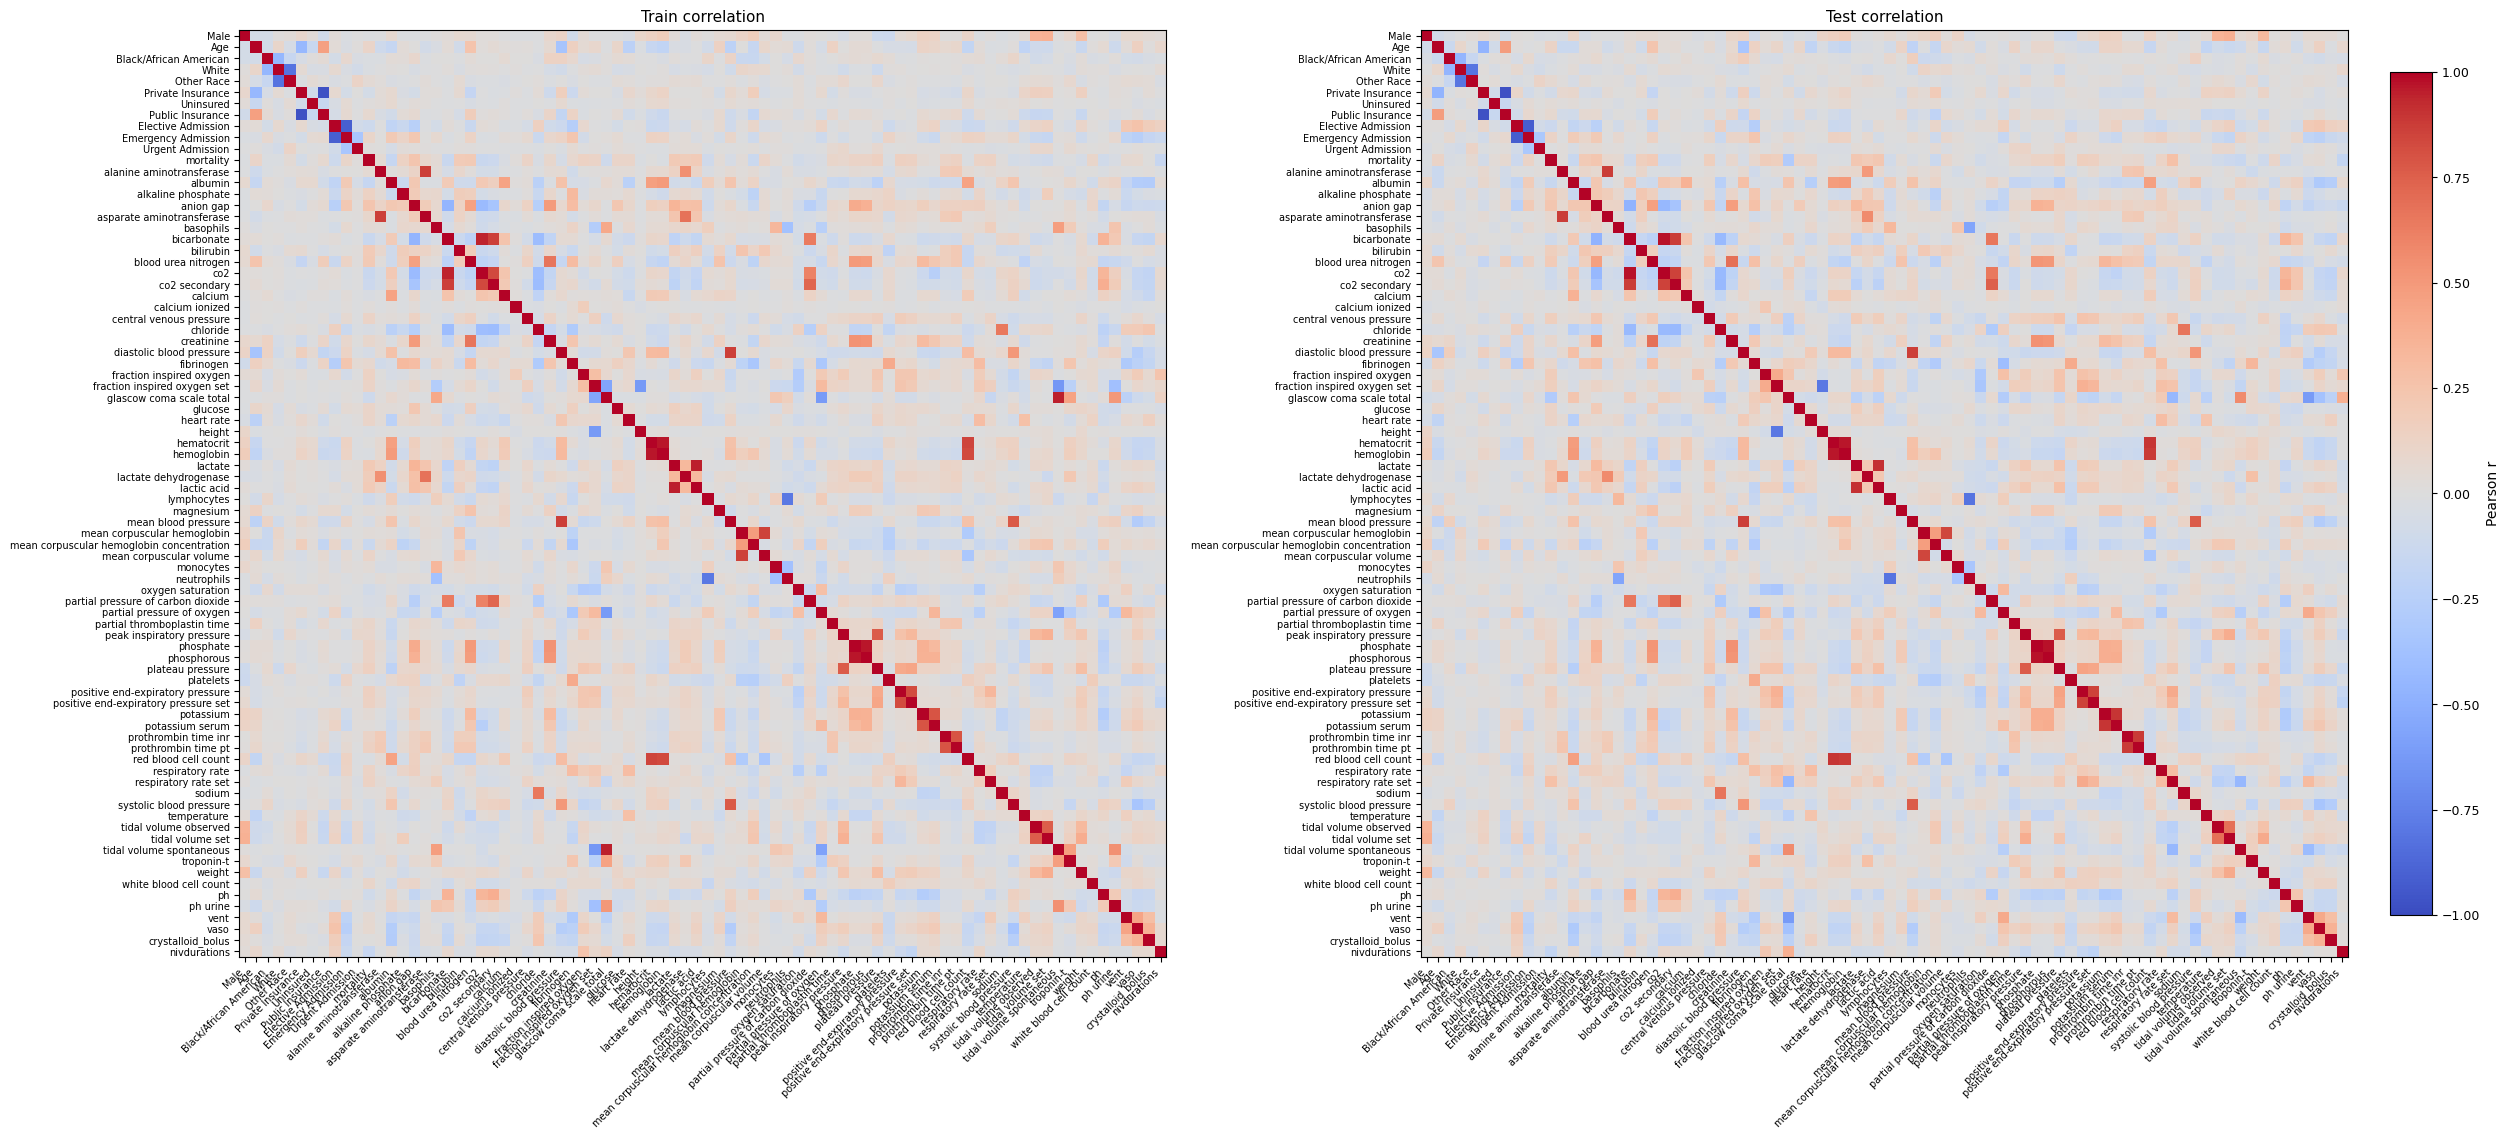

In [28]:
train_corr = train.corr()
test_corr  = test.corr()
n = train_corr.shape[1]

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(25,20), constrained_layout=True)
for ax, corr, title in zip(axes, (train_corr, test_corr), ("Train correlation", "Test correlation")):
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.02, label="Pearson r").ax.tick_params(labelsize=9)

In [29]:
df.columns

Index(['Male', 'Age', 'Black/African American', 'White', 'Other Race',
       'Private Insurance', 'Uninsured', 'Public Insurance',
       'Elective Admission', 'Emergency Admission', 'Urgent Admission',
       'mortality', 'alanine aminotransferase', 'albumin',
       'alkaline phosphate', 'anion gap', 'asparate aminotransferase',
       'basophils', 'bicarbonate', 'bilirubin', 'blood urea nitrogen', 'co2',
       'co2 secondary', 'calcium', 'calcium ionized',
       'central venous pressure', 'chloride', 'creatinine',
       'diastolic blood pressure', 'fibrinogen', 'fraction inspired oxygen',
       'fraction inspired oxygen set', 'glascow coma scale total', 'glucose',
       'heart rate', 'height', 'hematocrit', 'hemoglobin', 'lactate',
       'lactate dehydrogenase', 'lactic acid', 'lymphocytes', 'magnesium',
       'mean blood pressure', 'mean corpuscular hemoglobin',
       'mean corpuscular hemoglobin concentration', 'mean corpuscular volume',
       'monocytes', 'neutrophils',

In [30]:
train = pd.read_csv('data/normalized_train.csv')


In [31]:
import statsmodels.api as sm

def prepare_mimic(df):
    """
    SOFA-aligned feature selection:
    - Respiratory: PaO2/FiO2 ratio (use SpO2 & FiO2 as proxy), mechanical ventilation
    - Cardiovascular: MAP, vasopressor, lactate
    - Renal: creatinine
    - Coagulation: platelets
    - Hepatic: bilirubin
    - Neurological: GCS
    - Demographics & admission context
    """
    features_df = pd.DataFrame({
        # Respiratory (PaO2/FiO2 is the SOFA input; use available proxies)
        'Oxygen Saturation': df['oxygen saturation'],
        'Fraction Inspired Oxygen': df['fraction inspired oxygen'],
        'Mechanical Ventilation': df['vent'],

        # Cardiovascular
        'Mean Blood Pressure': df['mean blood pressure'],
        'Vasopressor': df['vaso'],
        'Lactate': df['lactate'],

        # Renal
        'Creatinine': df['creatinine'],

        # Coagulation
        'Platelets': df['platelets'],

        # Hepatic (was missing before)
        'Bilirubin': df['bilirubin'],

        # Neurological (was missing before)
        'GCS Total': df['glascow coma scale total'],

        # Demographics
        'Age': df['Age'],
        'Male': df['Male'],
        'Black/African American': df['Black/African American'],
        'Other Race': df['Other Race'],
    })

    label = df['mortality']
    return features_df, label


def fit_mimic_regression(df):
    features_df, label = prepare_mimic(df)
    X = sm.add_constant(features_df)
    return sm.Logit(label, X).fit(disp=0), features_df.columns.tolist()


from pathlib import Path


model_real, features = fit_mimic_regression(train)

# Extract coefficients and CIs (drop intercept)
coefs_real = model_real.params[1:]
ci_real = model_real.conf_int().iloc[1:]


In [32]:
model_real.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              mortality   No. Observations:                22075
Model:                          Logit   Df Residuals:                    22060
Method:                           MLE   Df Model:                           14
Date:                Mon, 02 Mar 2026   Pseudo R-squ.:                  0.3080
Time:                        16:33:39   Log-Likelihood:                -4596.0
converged:                       True   LL-Null:                       -6642.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       18.1978      0.997     18.254      0.000      16.244      20.152
Oxygen Saturation           -2.7389      0.546     -5.015      0.000      -3.809      -1.669
Fraction Inspired Oxygen    19.8658      0.690     28.805      0.000      18.514      21.217
Mechanical Ventilation      -1.2796      0.074    -17.364      0.000      -1.424      -1.135
Mean Blood Pressure         -0.7391      0.309     -2.391      0.017      -1.345      -0.133
Vasopressor                 -0.7218      0.070    -10.308      0.000      -0.859      -0.585
Lactate                     22.3499      2.409      9.279      0.000      17.629      27.071
Creatinine                   4.4206      0.530      8.343      0.000       3.382       5.459
Platelets                    1.3290      0.405      3.285      0.001       0.536       2.122
Bilirubin                   10.5904      0.559     18.930      0.000       9.494      11.687
GCS Total                 -620.5172     14.646    -42.368      0.000    -649.222    -591.812
Age                          2.6232      0.149     17.603      0.000       2.331       2.915
Male                        -0.3356      0.058     -5.805      0.000      -0.449      -0.222
Black/African American      -0.3157      0.125     -2.522      0.012      -0.561      -0.070
Other Race                   0.1748      0.066      2.644      0.008       0.045       0.304
============================================================================================
"""

In [33]:
# Assuming X_test is your test data with a constant added


features_df, label = prepare_mimic(train)
X = sm.add_constant(features_df)
#return sm.Logit(label, X)

predictions_prob = model_real.predict(X)

0.8834618330697623

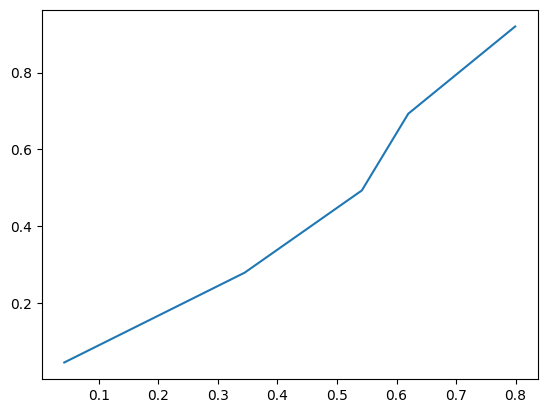

In [34]:
from sklearn.calibration import calibration_curve
x,y = calibration_curve(train['mortality'], predictions_prob)
plt.plot(x,y)

from sklearn.metrics import roc_auc_score

roc_auc_score(train['mortality'], predictions_prob)